In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
import ast
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow import keras


In [2]:
# -------------------------
# CONFIGURAÇÕES GERAIS
# -------------------------
PREDICTORS = ["PwmD", "PwmE"]
TARGET = ["Wd", "We"]
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET) 
TIME_STEPS = 3
NDATASETS = 4  # ajuste se houver mais datasets

In [3]:
# -------------------------
# LEITURA DOS DATASETS
# -------------------------
Datasets = []
for i in range(NDATASETS):
    Dataset = pd.read_csv(f"../Dados/TestData/Data{i + 1}.csv")
    Dataset.index = (np.arange(0, len(Dataset)) * 0.07).round(5)
    Datasets.append(Dataset)
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head())

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.28   3.28  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.21  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.28  0.0  0.7    0.0  0.0  0.0   3.28   3.28  68.95  68.95
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.02   3.02  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.21  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.28  0.0  0.7    0.0  0.0  0.0   3.02   3.02  63.44  63.44
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   

In [4]:
# -------------------------
# NORMALIZAÇÃO
# -------------------------
NormDatasets = []
SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = pd.read_csv(f"../Dados/Data1.csv")
SCALER.fit(TrainDataset[PREDICTORS])
OUT_SCALER.fit(TrainDataset[TARGET])

for i in range(NDATASETS):
    CurrentTestDataset = Datasets[i].copy()

    CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
    CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])

    NormDatasets.append(CurrentTestDataset)
    print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
    print(NormDatasets[i].head())


++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.21  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.28  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.404730  1.141992
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.21  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.28  0.0  0.7    0.0  0.107454  0.09236 

In [5]:
# -------------------------
# FUNÇÃO PARA CRIAR SEQUÊNCIAS
# -------------------------
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i - timesteps:i].values)
        Y_seq.append(target_data.iloc[i].values)
    return np.array(X_seq), np.array(Y_seq)

# Odometria 

- R = 0.032    Raio da roda (m)
- L = 0.125  Distância entre rodas (m)
- T = 0.07     Período de amostragem (s)

- $x_{k+1} = x_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \cos(\theta_k)$

- $  y_{k+1} = y_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \sin(\theta_k)  $

- $ \theta_{k+1} = \theta_k + \frac{R . T}{2L} . (\phi_d[k] - \phi_e[k]) $



In [6]:
R = 0.032   
L = 0.124/2  
T = 0.07   

def Odometry(Wd, We, x0=0, y0=0.7, theta0=0):

    n = len(Wd)
    X_est, Y_est, Theta_est = [x0], [y0], [theta0]

    for k in range(n - 1):
        theta_k = Theta_est[-1]

        # Cinemática diferencial
        x_next = X_est[-1] + (R * T / 2) * (np.cos(theta_k) * (Wd[k] + We[k]))
        y_next = Y_est[-1] + (R * T / 2) * (np.sin(theta_k) * (Wd[k] + We[k]))
        theta_next = Theta_est[-1] + (R * T / (2 * L)) * (Wd[k] - We[k])

        X_est.append(x_next)
        Y_est.append(y_next)
        Theta_est.append(theta_next)

    return np.array(X_est), np.array(Y_est), np.array(Theta_est)



In [7]:
import matplotlib.pyplot as plt
import numpy as np

def PlotTrajectoryEvolution(X_true, Y_true, Theta_true, X_est, Y_est, Theta_est, title):
    """
    Exibe 3 gráficos discretos (X, Y, Θ) em função do tempo (ou iteração k).
    Cada gráfico mostra amostras reais e estimadas.
    """
    k = np.arange(len(X_true))
    time = (k * T).round(5)

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # --- X ---
    axs[0].scatter(time, X_true, marker='o', s=15, label='X verdadeiro', color='blue', alpha=0.7)
    axs[0].scatter(time, X_est, marker='x', s=15, label='X estimado', color='red', alpha=0.7)
    axs[0].set_ylabel('X [m]')
    axs[0].legend()
    axs[0].grid(True)

    # --- Y ---
    axs[1].scatter(time, Y_true, marker='o', s=15, label='Y verdadeiro', color='blue', alpha=0.7)
    axs[1].scatter(time, Y_est, marker='x', s=15, label='Y estimado', color='red', alpha=0.7)
    axs[1].set_ylabel('Y [m]')
    axs[1].legend()
    axs[1].grid(True)

    # --- Theta ---
    axs[2].scatter(time, Theta_true, marker='o', s=15, label=r'$\theta$ verdadeiro', color='blue', alpha=0.7)
    axs[2].scatter(time, Theta_est, marker='x', s=15, label=r'$\theta$ estimado', color='red', alpha=0.7)
    axs[2].set_xlabel('Tempo [s]')
    axs[2].set_ylabel(r'$\theta$ [rad]')
    axs[2].legend()
    axs[2].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [8]:
# -------------------------
# SELECIONA OS 5 MELHORES MODELOS
# -------------------------
SORT_BY = "R2_Test_We"  # coluna usada para classificar os modelos

results_df = pd.read_excel("./resultados.xlsx")
results_df = results_df.sort_values(SORT_BY, ascending=False)
ModelsConfs = results_df.head(4).reset_index(drop=True)

print("+++++ Top 4 modelos selecionados +++++")
display(ModelsConfs)

+++++ Top 4 modelos selecionados +++++


,model,Neurons,R2_Train_Wd,MSE_Train_Wd,R2_Val_Wd,MSE_Val_Wd,R2_Test_Wd,MSE_Test_Wd,R2_Train_We,MSE_Train_We,R2_Val_We,MSE_Val_We,R2_Test_We,MSE_Test_We,W0,Wf
0,model_24_8,24,[0.9135335744821059],[0.3221942517531271],[0.9420071082056367],[0.24600237797196228],[0.9364889233482163],[0.32936002150467186],[0.9277227073219289],[0.259099233340521],[0.9290373075822367],[0.29920791829705834],[0.8989302406968759],[0.5372131806661751],"[[[-0.37689998745918274, -0.39590001106262207,...","[[[-0.3131999969482422, -0.5080000162124634, -..."
1,model_14_0,14,[0.9111602254223441],[0.3310379089284861],[0.9361438542454895],[0.2708739505426875],[0.9358860835143455],[0.33248626894236166],[0.9237317397710306],[0.273406031428966],[0.9300044405453745],[0.2951300876686294],[0.8961835877049287],[0.551812386206626],"[[[0.007400000002235174, 0.15610000491142273, ...","[[[0.009999999776482582, 0.21719999611377716, ..."
2,model_22_2,22,[0.9124203411059553],[0.3263424213172922],[0.9428420605387532],[0.24246056012007405],[0.9348244542729346],[0.3379917374088811],[0.9249226513073638],[0.26913685843414054],[0.9352873769071579],[0.27285505359862294],[0.895413887533685],[0.5559035513583407],"[[[0.0471000000834465, 0.06769999861717224, -0...","[[[0.11649999767541885, -0.007799999788403511,..."
3,model_21_6,21,[0.910878609998562],[0.3320872742769917],[0.9436860743844475],[0.23888030387387243],[0.9371038560656968],[0.32617106197618334],[0.9285942480332778],[0.2559749390875335],[0.935930706134199],[0.27014251279380913],[0.894568292390432],[0.5603981188688893],"[[[0.035999998450279236, 0.051600001752376556,...","[[[0.054099999368190765, 0.2734000086784363, 0..."




===== Avaliando Dataset 1 =====
R2_X = 0.9997, MSE_X = 0.000032
R2_Y = 0.9998, MSE_Y = 0.000013
R2_Theta = 0.9989, MSE_Theta = 0.000320


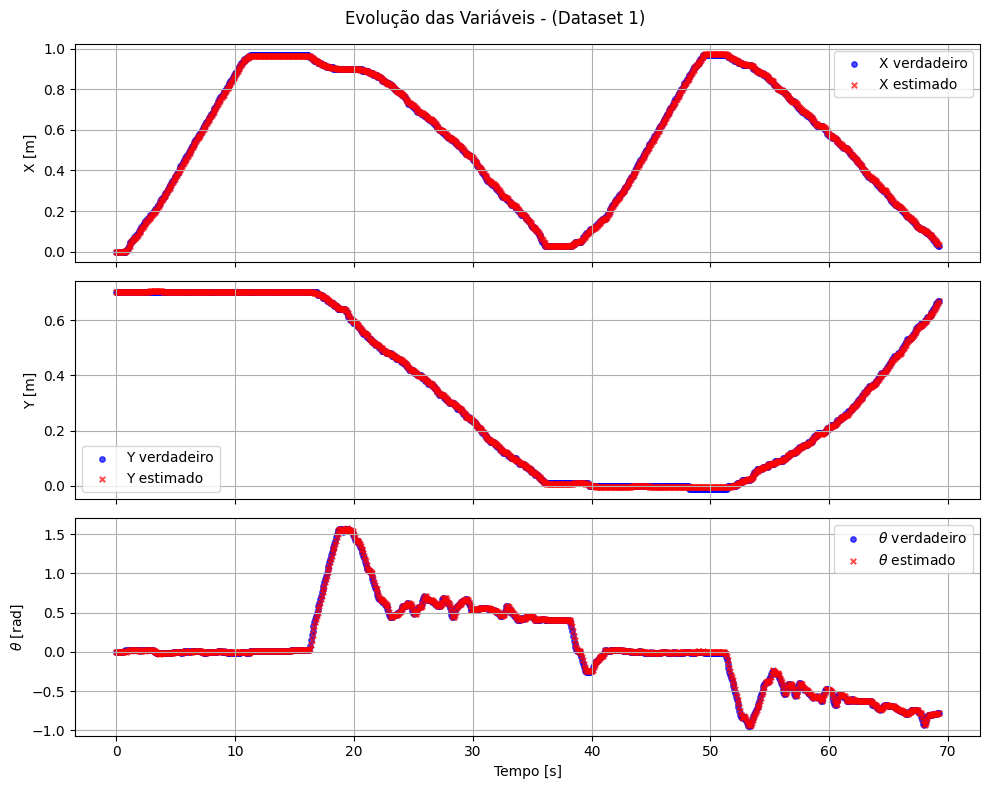



===== Avaliando Dataset 2 =====
R2_X = 0.9998, MSE_X = 0.000020
R2_Y = 0.9997, MSE_Y = 0.000013
R2_Theta = 0.9999, MSE_Theta = 0.000270


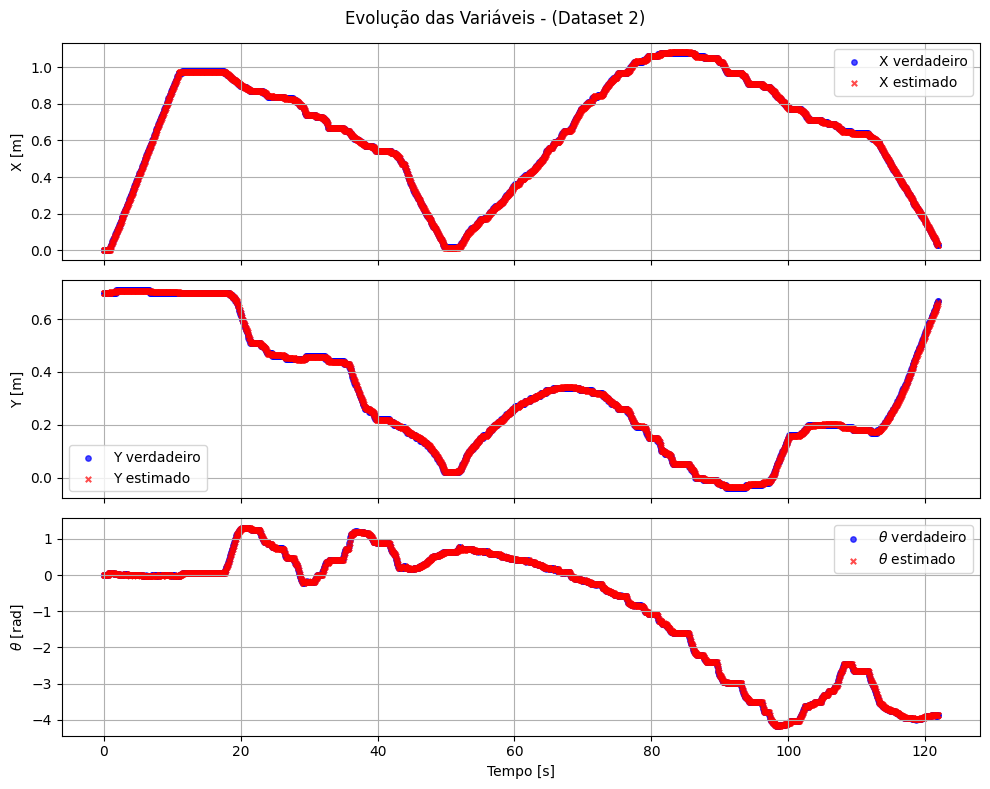



===== Avaliando Dataset 3 =====
R2_X = 0.9997, MSE_X = 0.000026
R2_Y = 0.9998, MSE_Y = 0.000014
R2_Theta = 0.9996, MSE_Theta = 0.000159


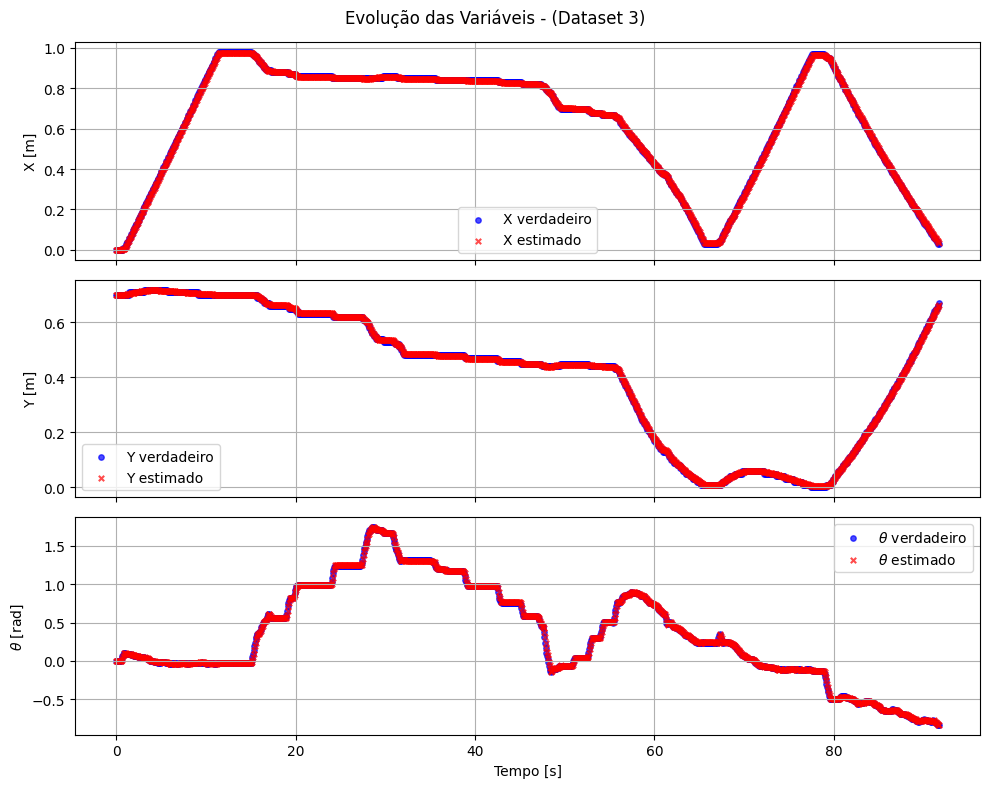



===== Avaliando Dataset 4 =====
R2_X = 0.9997, MSE_X = 0.000029
R2_Y = 0.9998, MSE_Y = 0.000014
R2_Theta = 0.9996, MSE_Theta = 0.000128


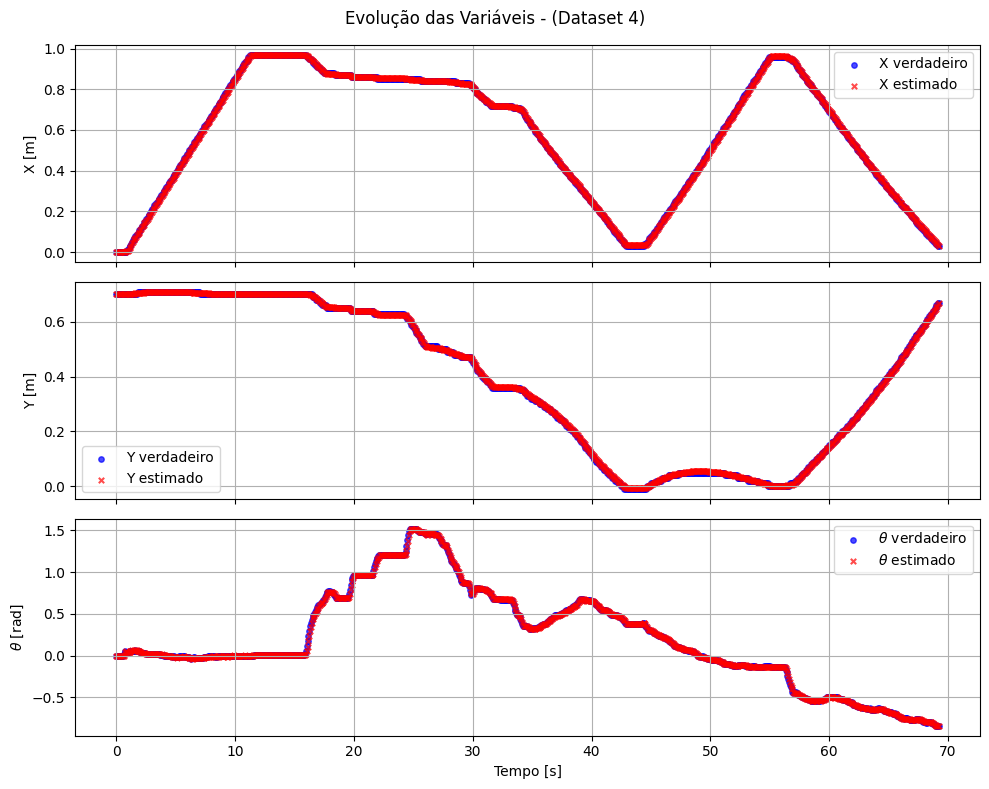

In [9]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------
# RECONSTRUÇÃO E AVALIAÇÃO
# -------------------------

results = []  # lista para armazenar métricas

# Correção: iteração simultânea deve usar zip()
for i, (NormDataset, Dataset) in enumerate(zip(NormDatasets, Datasets)):
    x_test, y_test = CreateSequences(NormDataset[PREDICTORS], NormDataset[TARGET], TIME_STEPS)
    Wd_We_true = OUT_SCALER.inverse_transform(y_test)

    X_true = Dataset["X"].values
    Y_true = Dataset["Y"].values
    Theta_true = Dataset["Theta"].values

    print(f"\n\n===== Avaliando Dataset {i+1} =====")

    # --- Extrai velocidades previstas ---
    Wd_pred = Dataset["Wd"].values  # ωd (roda direita)
    We_pred = Dataset["We"].values   # ωe (roda esquerda)

    # --- Calcula odometria estimada ---
    X_est, Y_est, Theta_est = Odometry(Wd_pred, We_pred)

    # Garante que os tamanhos batem
    min_len = min(len(X_true), len(X_est))
    X_true, Y_true, Theta_true = X_true[:min_len], Y_true[:min_len], Theta_true[:min_len]
    X_est, Y_est, Theta_est = X_est[:min_len], Y_est[:min_len], Theta_est[:min_len]

    # --- Cálculo das métricas ---
    r2_x = r2_score(X_true, X_est)
    r2_y = r2_score(Y_true, Y_est)
    r2_theta = r2_score(Theta_true, Theta_est)

    mse_x = mean_squared_error(X_true, X_est)
    mse_y = mean_squared_error(Y_true, Y_est)
    mse_theta = mean_squared_error(Theta_true, Theta_est)

    # print(f"\n===== {Name} =====")
    print(f"R2_X = {r2_x:.4f}, MSE_X = {mse_x:.6f}")
    print(f"R2_Y = {r2_y:.4f}, MSE_Y = {mse_y:.6f}")
    print(f"R2_Theta = {r2_theta:.4f}, MSE_Theta = {mse_theta:.6f}")

    # --- Armazena resultados ---
    results.append({
        "Dataset": i + 1,
        "R2_X": r2_x, "MSE_X": mse_x,
        "R2_Y": r2_y, "MSE_Y": mse_y,
        "R2_Theta": r2_theta, "MSE_Theta": mse_theta
    })

    # --- Gera gráfico ---
    PlotTrajectoryEvolution(
        X_true, Y_true, Theta_true,
        X_est, Y_est, Theta_est,
        f"Evolução das Variáveis - (Dataset {i+1})"
    )

In [10]:
results_df = pd.DataFrame(results)
display(results_df)


,Dataset,R2_X,MSE_X,R2_Y,MSE_Y,R2_Theta,MSE_Theta
0,1,0.999689,0.000032,0.999836,0.000013,0.998878,0.000320
1,2,0.999793,0.000020,0.999745,0.000013,0.999909,0.000270
2,3,0.999682,0.000026,0.999771,0.000014,0.999606,0.000159
3,4,0.999688,0.000029,0.999816,0.000014,0.999621,0.000128
